In [49]:
import numpy as np
import pandas as pd
import os

DATA_DIR = os.getcwd()

In [50]:
# ── Load data hasil augmentasi Mixup ─────────────────────────────────────────
questions_emb  = np.load(os.path.join(DATA_DIR, 'questions_emb.npy'))
answerkeys_emb = np.load(os.path.join(DATA_DIR, 'answerkeys_emb.npy'))
answers_emb    = np.load(os.path.join(DATA_DIR, 'answers_emb.npy'))
metadata       = pd.read_pickle(os.path.join(DATA_DIR, 'metadata.pkl'))
metadata       = metadata.reset_index(drop=True)

print("=== Hasil Load ===")
print(f"questions_emb  : {questions_emb.shape}")
print(f"answerkeys_emb : {answerkeys_emb.shape}")
print(f"answers_emb    : {answers_emb.shape}")
print(f"Metadata       : {len(metadata)} rows")

=== Hasil Load ===
questions_emb  : (12, 135, 768)
answerkeys_emb : (12, 90, 768)
answers_emb    : (817, 80, 768)
Metadata       : 817 rows


In [51]:
# ── Analisis lubang (grade = 0 sampel per IDPSJ) ──────────────────────────────
pivot = (metadata.groupby(['IDPSJ', 'grade'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(columns=range(1, 11), fill_value=0))

print("Distribusi sebelum Cross-Prompt Injection:")
print(pivot.to_string())

# Daftar lubang: (IDPSJ_target, grade)
holes = [(psj, g)
         for psj in pivot.index
         for g in range(1, 11)
         if pivot.loc[psj, g] == 0]

print(f"\nTotal lubang (grade=0): {len(holes)}")
for h in holes:
    print(f"  IDPSJ {h[0]:>2}  grade {h[1]}")

Distribusi sebelum Cross-Prompt Injection:
grade  1   2   3   4   5   6   7   8   9   10
IDPSJ                                        
1       9   1   0   9   1  25   3  11   5  37
2       1   0  15   0   5   5   0  10   0   5
3       5   0   0   4   1  10   0   6   0   7
4       0   2   3  11   1   5   5   0   1   4
5      17   0   5   0   5   5   2   3   0   5
6      22   0   0   0   5   5   5   0   0   7
7       6   0   3   0   8   5   2   3   0  13
8       0   0  12   6  11   7   3  10  10  53
9      14   0   9   9   1  10  10   2   1  47
10      5   8   0  10   0  10  18  23  19  21
11      6  42  17   0  10   0  13  10   0  22
12      4   0   1   0   5   0  14   6   3   2

Total lubang (grade=0): 33
  IDPSJ  1  grade 3
  IDPSJ  2  grade 2
  IDPSJ  2  grade 4
  IDPSJ  2  grade 7
  IDPSJ  2  grade 9
  IDPSJ  3  grade 2
  IDPSJ  3  grade 3
  IDPSJ  3  grade 7
  IDPSJ  3  grade 9
  IDPSJ  4  grade 1
  IDPSJ  4  grade 8
  IDPSJ  5  grade 2
  IDPSJ  5  grade 4
  IDPSJ  5  grade 9
  IDP

In [52]:
# ── Cross-Prompt Injection ────────────────────────────────────────────────────
# Strategi:
#   Untuk setiap lubang (IDPSJ_target, grade_target):
#   1. Hitung target = ceil(max_cls_IDPSJ / 2)  → konsisten dengan Mixup
#   2. Cari donor: IDPSJ lain yang PUNYA grade_target
#   3. Ambil (target) answer embeddings dari donor (acak, dengan penggantian)
#   4. Label tetap = grade_target
# Catatan penting:
#   questions_emb dan answerkeys_emb disimpan COMPACT (1 baris per IDPSJ),
#   jadi saat CPI kita hanya menambah answers + metadata.

RNG = np.random.default_rng(seed=42)

inj_answers = []
inj_meta = []

for (tgt_psj, tgt_grade) in holes:
    # Target per kelas = ceil(max kelas IDPSJ ini / 2)  — sama dengan Mixup
    local_max = pivot.loc[tgt_psj].max()
    n_inject = int(np.ceil(local_max / 2))

    # Cari donor: IDPSJ lain yang punya grade_target
    donor_mask = (
        (metadata['IDPSJ'] != tgt_psj) &
        (metadata['grade'] == tgt_grade)
    )
    donor_idx = metadata.index[donor_mask].values

    if len(donor_idx) == 0:
        print(f"  [SKIP] IDPSJ={tgt_psj} grade={tgt_grade} - tidak ada donor!")
        continue

    print(f"  IDPSJ={tgt_psj} grade={tgt_grade}  target={n_inject}  donor={len(donor_idx)}")

    # Ambil n_inject sampel dari donor (dengan penggantian jika donor sedikit)
    sampled = RNG.choice(donor_idx, size=n_inject, replace=len(donor_idx) < n_inject)

    # CPI menambah answer dari donor
    inj_answers.append(answers_emb[sampled])

    # Metadata sintetik
    for k in range(n_inject):
        inj_meta.append({
            'IDJwb': f'cpi_{tgt_psj}_{tgt_grade}_{k}',
            'IDPSJ': tgt_psj,
            'grade': tgt_grade,
        })

# ── Gabungkan ─────────────────────────────────────────────────────────────────
if inj_answers:
    final_answers_emb = np.vstack([answers_emb] + inj_answers)
    final_metadata = pd.concat(
        [metadata.drop(columns=['psj_idx'], errors='ignore'), pd.DataFrame(inj_meta)],
        ignore_index=True,
    )
else:
    final_answers_emb = answers_emb.copy()
    final_metadata = metadata.drop(columns=['psj_idx'], errors='ignore').copy()

# Tetap compact: 1 baris per IDPSJ
final_questions_emb = questions_emb.copy()
final_answerkeys_emb = answerkeys_emb.copy()

n_inj = len(final_metadata) - len(metadata)
print(f"\nData sebelum CPI : {len(metadata)}")
print(f"Data injeksi CPI : {n_inj}")
print(f"Total akhir      : {len(final_metadata)}")
print(f"\nfinal_answers_emb    : {final_answers_emb.shape}")
print(f"final_questions_emb  : {final_questions_emb.shape} (compact per IDPSJ)")
print(f"final_answerkeys_emb : {final_answerkeys_emb.shape} (compact per IDPSJ)")

  IDPSJ=1 grade=3  target=19  donor=65
  IDPSJ=2 grade=2  target=8  donor=53
  IDPSJ=2 grade=4  target=8  donor=49
  IDPSJ=2 grade=7  target=8  donor=75
  IDPSJ=2 grade=9  target=8  donor=39
  IDPSJ=3 grade=2  target=5  donor=53
  IDPSJ=3 grade=3  target=5  donor=65
  IDPSJ=3 grade=7  target=5  donor=75
  IDPSJ=3 grade=9  target=5  donor=39
  IDPSJ=4 grade=1  target=6  donor=89
  IDPSJ=4 grade=8  target=6  donor=84
  IDPSJ=5 grade=2  target=9  donor=53
  IDPSJ=5 grade=4  target=9  donor=49
  IDPSJ=5 grade=9  target=9  donor=39
  IDPSJ=6 grade=2  target=11  donor=53
  IDPSJ=6 grade=3  target=11  donor=65
  IDPSJ=6 grade=4  target=11  donor=49
  IDPSJ=6 grade=8  target=11  donor=84
  IDPSJ=6 grade=9  target=11  donor=39
  IDPSJ=7 grade=2  target=7  donor=53
  IDPSJ=7 grade=4  target=7  donor=49
  IDPSJ=7 grade=9  target=7  donor=39
  IDPSJ=8 grade=1  target=27  donor=89
  IDPSJ=8 grade=2  target=27  donor=53
  IDPSJ=9 grade=2  target=24  donor=53
  IDPSJ=10 grade=3  target=12  donor=65
 

Distribusi setelah Cross-Prompt Injection:
grade  1   2   3   4   5   6   7   8   9   10
IDPSJ                                        
1       9   1  19   9   1  25   3  11   5  37
2       1   8  15   8   5   5   8  10   8   5
3       5   5   5   4   1  10   5   6   5   7
4       6   2   3  11   1   5   5   6   1   4
5      17   9   5   9   5   5   2   3   9   5
6      22  11  11  11   5   5   5  11  11   7
7       6   7   3   7   8   5   2   3   7  13
8      27  27  12   6  11   7   3  10  10  53
9      14  24   9   9   1  10  10   2   1  47
10      5   8  12  10  12  10  18  23  19  21
11      6  42  17  21  10  21  13  10  21  22
12      4   7   1   7   5   7  14   6   3   2

Sisa lubang setelah CPI: 0


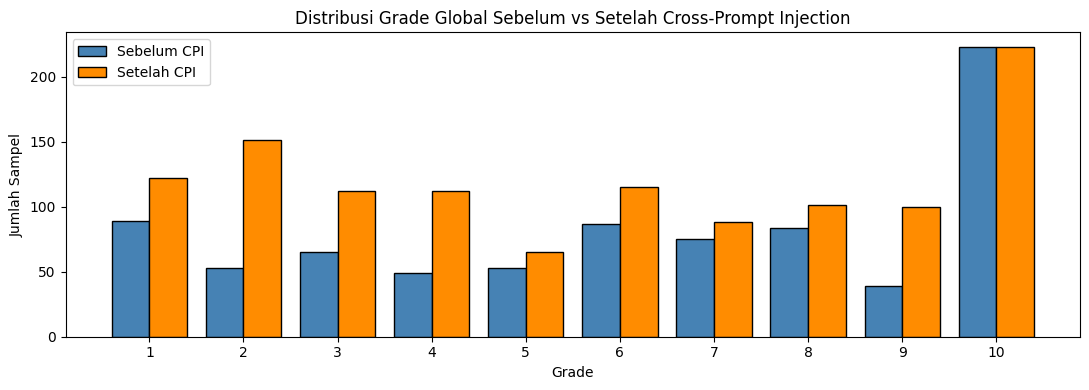

In [53]:
# ── Verifikasi distribusi setelah CPI ─────────────────────────────────────────
import matplotlib.pyplot as plt

pivot_final = (final_metadata.groupby(['IDPSJ', 'grade'])
                             .size()
                             .unstack(fill_value=0)
                             .reindex(columns=range(1, 11), fill_value=0))

print("Distribusi setelah Cross-Prompt Injection:")
print(pivot_final.to_string())

sisa_holes = [(psj, g)
              for psj in pivot_final.index
              for g in range(1, 11)
              if pivot_final.loc[psj, g] == 0]
print(f"\nSisa lubang setelah CPI: {len(sisa_holes)}")
if sisa_holes:
    for h in sisa_holes:
        print(f"  IDPSJ={h[0]} grade={h[1]} — tidak ada donor di seluruh dataset")

# Bar chart distribusi global sebelum vs sesudah
before = metadata['grade'].value_counts().sort_index()
after  = final_metadata['grade'].value_counts().sort_index()

x = np.arange(1, 11)
w = 0.4
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, [before.get(g, 0) for g in x], w, label='Sebelum CPI', color='steelblue',  edgecolor='black')
ax.bar(x + w/2, [after.get(g,  0) for g in x], w, label='Setelah CPI', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xlabel('Grade')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Grade Global Sebelum vs Setelah Cross-Prompt Injection')
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
# ── Simpan hasil akhir ───────────────────────────────────────────────────────
# answers_emb : simpan penuh karena setiap sampel unik
# questions & answerkeys : simpan HANYA 1 per IDPSJ (hemat storage)
#   -> rekonstruksi di training menggunakan kolom psj_idx di metadata

import pickle

# Buat mapping IDPSJ -> indeks unik
idpsj_sorted = sorted(final_metadata['IDPSJ'].unique())
idpsj_to_idx = {psj: i for i, psj in enumerate(idpsj_sorted)}
final_metadata = final_metadata.copy()
final_metadata['psj_idx'] = final_metadata['IDPSJ'].map(idpsj_to_idx)

# Handle dua kemungkinan format input:
# 1) compact (n_idpsj, seq_len, 300)
# 2) expanded (n_samples, seq_len, 300) -> dipadatkan lagi
if final_questions_emb.shape[0] == len(idpsj_sorted):
    uniq_questions_emb = final_questions_emb
elif final_questions_emb.shape[0] == len(final_metadata):
    uniq_q_rows = [final_metadata.index[final_metadata['IDPSJ'] == psj][0] for psj in idpsj_sorted]
    uniq_questions_emb = final_questions_emb[uniq_q_rows]
else:
    raise ValueError(
        f"Ukuran final_questions_emb tidak cocok: {final_questions_emb.shape[0]} "
        f"(expected {len(idpsj_sorted)} atau {len(final_metadata)})"
    )

if final_answerkeys_emb.shape[0] == len(idpsj_sorted):
    uniq_answerkeys_emb = final_answerkeys_emb
elif final_answerkeys_emb.shape[0] == len(final_metadata):
    uniq_q_rows = [final_metadata.index[final_metadata['IDPSJ'] == psj][0] for psj in idpsj_sorted]
    uniq_answerkeys_emb = final_answerkeys_emb[uniq_q_rows]
else:
    raise ValueError(
        f"Ukuran final_answerkeys_emb tidak cocok: {final_answerkeys_emb.shape[0]} "
        f"(expected {len(idpsj_sorted)} atau {len(final_metadata)})"
    )

# Simpan
np.save(os.path.join(DATA_DIR, 'aug_answers_emb.npy'), final_answers_emb)
np.save(os.path.join(DATA_DIR, 'aug_questions_emb.npy'), uniq_questions_emb)
np.save(os.path.join(DATA_DIR, 'aug_answerkeys_emb.npy'), uniq_answerkeys_emb)

# Simpan metadata dengan pickle protocol 4 (lebih kompatibel lintas environment)
with open(os.path.join(DATA_DIR, 'aug_metadata.pkl'), 'wb') as f:
    pickle.dump(final_metadata, f, protocol=4)

print("File tersimpan:")
print(f"  aug_answers_emb.npy      {final_answers_emb.shape}   (per sampel)")
print(f"  aug_questions_emb.npy    {uniq_questions_emb.shape}  (per IDPSJ unik)")
print(f"  aug_answerkeys_emb.npy   {uniq_answerkeys_emb.shape} (per IDPSJ unik)")
print(f"  aug_metadata.pkl         {len(final_metadata)} rows  (+ kolom psj_idx)")

before_mb = (final_questions_emb.nbytes + final_answerkeys_emb.nbytes) / 1024**2
after_mb = (uniq_questions_emb.nbytes + uniq_answerkeys_emb.nbytes) / 1024**2
print(f"\nHemat storage questions+answerkeys: {before_mb:.1f} MB -> {after_mb:.1f} MB")

File tersimpan:
  aug_answers_emb.npy      (1189, 80, 768)   (per sampel)
  aug_questions_emb.npy    (12, 135, 768)  (per IDPSJ unik)
  aug_answerkeys_emb.npy   (12, 90, 768) (per IDPSJ unik)
  aug_metadata.pkl         1189 rows  (+ kolom psj_idx)

Hemat storage questions+answerkeys: 15.8 MB -> 15.8 MB
